# Random teacher outputs
Across MLP variants (i.e. activation with/without ReLU or RMSNorm, Linear layers with/without bias, and different input/output/model dimensionalities), normally distributed input vectors result in a long-tailed output class distribution.

In [1]:
import itertools

from matplotlib import pyplot as plt

import torch
import torch.nn.functional as F

# Random normal inputs

In [ ]:
NUM_SAMPLES = int(1e5)

DIM_OUT = [16,32,64]
DIM_INP = [16,128,1024,8192]


fig, axes = plt.subplots(len(DIM_OUT), len(DIM_INP), figsize=(2*len(DIM_INP), 2*len(DIM_OUT)))  

axes = axes.flatten()
for i, (d_out, d_inp) in enumerate(itertools.product(DIM_OUT, DIM_INP)):
    print(f"Testing d_out={d_out}, d_inp={d_inp}")
    bins = list(range(d_out+1))
    x = torch.randn(int(NUM_SAMPLES), d_inp)
    w = torch.randn(d_out, d_inp)

    # Forward pass
    y = F.softmax(x @ w.t(), dim=1)
    y = torch.argmax(y, dim=1)
    y = torch.histc(y.float(), bins=d_out, min=0, max=d_out).tolist()
    y = list(sorted(y))

    ax = axes[i]
    ax.hist(bins[:-1], bins, weights=y, density=True)
    ax.set_title(f"${d_inp} \\to {d_out}$")
    ax.set_xlim(0, d_out)
    ax.set_xticks(list(range(d_out)), minor=True)
    ax.set_ylim(1e-3, 1)
    ax.set_yscale('log')
    
# add pading between plots
plt.tight_layout()

In [ ]:
NUM_SAMPLES = int(1e5)

DIM_OUT = [1]
DIM_INP = [16,128,1024,8192]


fig, axes = plt.subplots(len(DIM_OUT), len(DIM_INP), figsize=(2*len(DIM_INP), 2*len(DIM_OUT)))  

axes = axes.flatten()
for i, (d_out, d_inp) in enumerate(itertools.product(DIM_OUT, DIM_INP)):
    d_out = d_out * d_inp
    print(f"Testing d_out={d_out}, d_inp={d_inp}")
    bins = list(range(d_out+1))
    x = torch.randn(int(NUM_SAMPLES), d_inp)
    w = torch.randn(d_out, d_inp)

    # Forward pass
    y = F.softmax(x @ w.t(), dim=1)
    y = torch.argmax(y, dim=1)
    y = torch.histc(y.float(), bins=d_out, min=0, max=d_out).tolist()
    y = list(sorted(y))

    ax = axes[i]
    ax.hist(bins[:-1], bins, weights=y, density=True)
    ax.set_title(f"${d_inp} \\to {d_out}$")
    ax.set_xlim(0, d_out)
    ax.set_xticks(list(range(d_out)), minor=True)
    ax.set_ylim(1e-5, 1)
    ax.set_yscale('log')
    
# add pading between plots
plt.tight_layout()

In [ ]:
NUM_SAMPLES = int(1e5)

DIM_OUT = [1]
DIM_INP = [16,128,1024,8192]


fig, axes = plt.subplots(len(DIM_OUT), len(DIM_INP), figsize=(2*len(DIM_INP), 2*len(DIM_OUT)))  

axes = axes.flatten()
for i, (d_out, d_inp) in enumerate(itertools.product(DIM_OUT, DIM_INP)):
    d_out = d_out * d_inp
    d_mid = d_inp
    print(f"Testing d_out={d_out}, d_inp={d_inp}")
    bins = list(range(d_out+1))
    x = torch.randn(int(NUM_SAMPLES), d_inp)
    w1 = torch.randn(d_mid, d_inp)
    w2 = torch.randn(d_out, d_mid)

    # Forward pass
    h = x @ w1.t()
    h = F.relu(h)
    y = h @ w2.t()
    y = torch.argmax(y, dim=1)
    y = torch.histc(y.float(), bins=d_out, min=0, max=d_out).tolist()
    y = list(sorted(y))

    ax = axes[i]
    ax.hist(bins[:-1], bins, weights=y, density=True)
    ax.set_title(f"${d_inp} \\to {d_mid} \\to {d_out}$\nReLU")
    ax.set_xlim(0, d_out)
    ax.set_xticks(list(range(d_out)), minor=True)
    ax.set_ylim(1e-5, 1)
    ax.set_yscale('log')
    
# add pading between plots
plt.tight_layout()

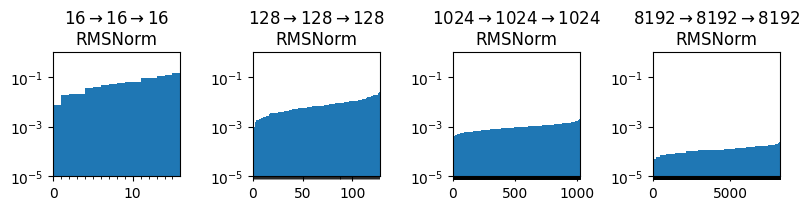

<Figure size 640x480 with 0 Axes>

In [ ]:
NUM_SAMPLES = int(1e5)

DIM_OUT = [1]
DIM_INP = [16,128,1024,8192]


fig, axes = plt.subplots(len(DIM_OUT), len(DIM_INP), figsize=(2*len(DIM_INP), 2*len(DIM_OUT)))  

axes = axes.flatten()
for i, (d_out, d_inp) in enumerate(itertools.product(DIM_OUT, DIM_INP)):
    d_out = d_out * d_inp
    d_mid = d_inp
    bins = list(range(d_out+1))
    print(f"Testing d_out={d_out}, d_inp={d_inp}")
    with torch.inference_mode():
        x = torch.randn(int(NUM_SAMPLES), d_inp)
        w1 = torch.randn(d_mid, d_inp)
        w2 = torch.randn(d_out, d_mid)

        # Forward pass
        h = x @ w1.t()
        h = F.rms_norm(h, (h.shape[-1],))
        y = h @ w2.t()
        y = torch.argmax(y, dim=1)
        y = torch.histc(y.float(), bins=d_out, min=0, max=d_out).tolist()
        y = list(sorted(y))

    ax = axes[i]
    ax.hist(bins[:-1], bins, weights=y, density=True)
    ax.set_title(f"${d_inp} \\to {d_mid} \\to {d_out}$\nRMSNorm")
    ax.set_xlim(0, d_out)
    ax.set_xticks(list(range(d_out)), minor=True)
    ax.set_ylim(1e-5, 1)
    ax.set_yscale('log')
    
# add pading between plots
plt.tight_layout()
display(fig)

Testing d_out=16, d_inp=16


Testing d_out=128, d_inp=128
Testing d_out=1024, d_inp=1024
Testing d_out=8192, d_inp=8192


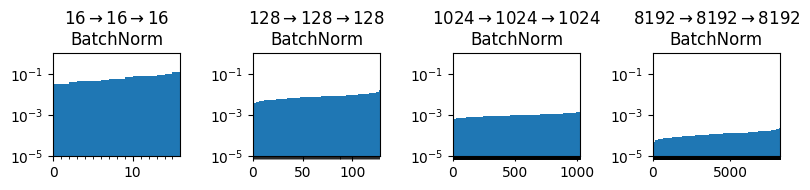

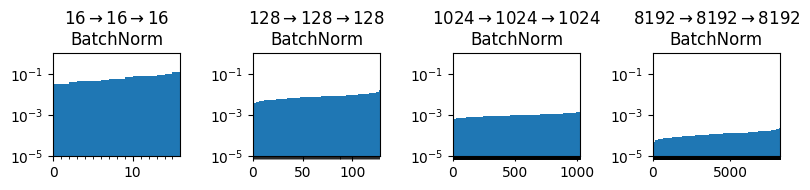

In [11]:
NUM_SAMPLES = int(1e5)

DIM_OUT = [1]
DIM_INP = [16,128,1024,8192]


fig, axes = plt.subplots(len(DIM_OUT), len(DIM_INP), figsize=(2*len(DIM_INP), 2*len(DIM_OUT)))  

axes = axes.flatten()
for i, (d_out, d_inp) in enumerate(itertools.product(DIM_OUT, DIM_INP)):
    d_out = d_out * d_inp
    d_mid = d_inp
    bins = list(range(d_out+1))
    print(f"Testing d_out={d_out}, d_inp={d_inp}")
    with torch.inference_mode():
        x = torch.randn(int(NUM_SAMPLES), d_inp)
        w1 = torch.randn(d_mid, d_inp)
        w2 = torch.randn(d_out, d_mid)

        # Forward pass
        h = x @ w1.t()
        h = F.batch_norm(h, h.mean(dim=0), h.std(dim=0), weight=None, bias=None, training=False)
        y = h @ w2.t()
        y = F.batch_norm(y, y.mean(dim=0), y.std(dim=0), weight=None, bias=None, training=False)
        y = torch.argmax(y, dim=1)
        y = torch.histc(y.float(), bins=d_out, min=0, max=d_out).tolist()
        y = list(sorted(y))

    ax = axes[i]
    ax.hist(bins[:-1], bins, weights=y, density=True)
    ax.set_title(f"${d_inp} \\to {d_mid} \\to {d_out}$\nBatchNorm")
    ax.set_xlim(0, d_out)
    ax.set_xticks(list(range(d_out)), minor=True)
    ax.set_ylim(1e-5, 1)
    ax.set_yscale('log')
    
# add pading between plots
plt.tight_layout()
display(fig)

## Random uniform [-1,1]

In [ ]:
NUM_SAMPLES = int(1e5)

DIM_OUT = [16,32,64,128]
DIM_INP = [16,128,1024,8192]


fig, axes = plt.subplots(len(DIM_OUT), len(DIM_INP), figsize=(2*len(DIM_INP), 2*len(DIM_OUT)))  

axes = axes.flatten()
for i, (d_out, d_inp) in enumerate(itertools.product(DIM_OUT, DIM_INP)):
    print(f"Testing d_out={d_out}, d_inp={d_inp}")
    bins = list(range(d_out+1))
    x = 2*(torch.rand(NUM_SAMPLES, d_inp)-0.5)
    w = 2*(torch.rand(d_out, d_inp)-0.5)

    # Forward pass
    y = F.softmax(x @ w.t(), dim=1)
    y = torch.argmax(y, dim=1)
    y = torch.histc(y.float(), bins=d_out, min=0, max=d_out).tolist()
    y = list(sorted(y))

    ax = axes[i]
    ax.hist(bins[:-1], bins, weights=y, density=True)
    ax.set_title(f"${d_inp} \\to {d_out}$")
    ax.set_xlim(0, d_out)
    ax.set_xticks(list(range(d_out)), minor=True)
    ax.set_ylim(1e-3, 1)
    ax.set_yscale('log')
    
# add pading between plots
plt.tight_layout()

## Random uniform [-1,1], normalized

In [ ]:
NUM_SAMPLES = int(1e5)

DIM_OUT = [16,32,64,128]
DIM_INP = [16,128,1024,8192]


fig, axes = plt.subplots(len(DIM_OUT), len(DIM_INP), figsize=(2*len(DIM_INP), 2*len(DIM_OUT)))  

axes = axes.flatten()
for i, (d_out, d_inp) in enumerate(itertools.product(DIM_OUT, DIM_INP)):
    print(f"Testing d_out={d_out}, d_inp={d_inp}")
    bins = list(range(d_out+1))
    x = 2*(torch.rand(NUM_SAMPLES, d_inp)-0.5)
    w = 2*(torch.rand(d_out, d_inp)-0.5)

    x = F.normalize(x, p=2, dim=1)
    w = F.normalize(w, p=2, dim=1)

    # Forward pass
    y = F.softmax(x @ w.t(), dim=1)
    y = torch.argmax(y, dim=1)
    y = torch.histc(y.float(), bins=d_out, min=0, max=d_out).tolist()
    y = list(sorted(y))

    ax = axes[i]
    ax.hist(bins[:-1], bins, weights=y, density=True)
    ax.set_title(f"${d_inp} \\to {d_out}$")
    ax.set_xlim(0, d_out)
    ax.set_xticks(list(range(d_out)), minor=True)
    ax.set_ylim(1e-3, 1)
    ax.set_yscale('log')
    
# add pading between plots
plt.tight_layout()

## Random uniform [-1,1], centered

In [ ]:
NUM_SAMPLES = int(1e5)

DIM_OUT = [16,32,64,128]
DIM_INP = [16,128,1024,8192]


fig, axes = plt.subplots(len(DIM_OUT), len(DIM_INP), figsize=(2*len(DIM_INP), 2*len(DIM_OUT)))  

axes = axes.flatten()
for i, (d_out, d_inp) in enumerate(itertools.product(DIM_OUT, DIM_INP)):
    print(f"Testing d_out={d_out}, d_inp={d_inp}")
    bins = list(range(d_out+1))
    x = 2*(torch.rand(NUM_SAMPLES, d_inp)-0.5)
    w = 2*(torch.rand(d_out, d_inp)-0.5)

    x -= x.mean(dim=0, keepdim=True)
    w -= w.mean(dim=0, keepdim=True)

    # Forward pass
    y = F.softmax(x @ w.t(), dim=1)
    y = torch.argmax(y, dim=1)
    y = torch.histc(y.float(), bins=d_out, min=0, max=d_out).tolist()
    y = list(sorted(y))

    ax = axes[i]
    ax.hist(bins[:-1], bins, weights=y, density=True)
    ax.set_title(f"${d_inp} \\to {d_out}$")
    ax.set_xlim(0, d_out)
    ax.set_xticks(list(range(d_out)), minor=True)
    ax.set_ylim(1e-3, 1)
    ax.set_yscale('log')
    
# add pading between plots
plt.tight_layout()

In [ ]:
y = F.softmax(x @ w.t(), dim=1)
torch.argmax(y, dim=1)

In [ ]:
y = F.softmax(x @ w.t(), dim=1)
torch.argmax(y, dim=1)